# Laboratorio 4 - Gymnasium

## Investigación

¿Qué es Gymnasium y qué problema resuelve? ¿Cómo se relaciona con OpenAI Gym?

Es una librería de Python que provee una API estándar para definir e interactuar con entornos de RL. Es útil porque, sin un estándar común, cada investigador tendría que programar su propia interfaz para cada entorno, complicando la comparación de algoritmos de forma justa.
Es el sucesor de OpenAI Gym, el cual dejó de mantenerse activamente, por lo que Farma tomó el proyecto, corrigió sus bugs y lo relanzó como Gymnasium, conservando la misma API (Farama Foundation, s. f.).

Estructura básica de un entorno (Env): métodos reset(), step(action), render() y close(). Describa qué recibe y qué retorna cada uno, incluyendo la tupla que retorna step().
- Resest(): reinicia el entorno. Retorna la observación inicial (observation) y un diccionario con información auxiliar (info), el cual se usa como diagnóstico y no debe usarse para tomar decisiones.
- Step(action): ejecuta una acción en el entorno. Retorna una tupla de 5 elementos: observation (nuevo estado tras la acción), reward (recompensa numérica obtenida en el paso), terminated (true si el episodio acabó por una razón natural del MDP), truncated (true si el episodio terminó por una razón externa al MDP), info (diccionario con datos extra de diagnóstico).
- Render(): genera una representación visual del estado actual.
- Close(): libera recursos al terminar d eusar el entorno.

Espacios de observación y acción (Spaces): investigue al menos Discrete, Box y MultiDiscrete. ¿Qué representa cada uno y en qué tipo de entornos se utilizan?
Los Space definen la forma y el tipo de datos válidos para observaciones y acciones.
- Discrete: entorno entre 0 y n – 1. Se usa cuando hay un número infinito de opciones o estados discretos.
- Box: un array de números continuos dentro de un rango, con una forma definida. Se usa para variables continuas.
- MultiDiscrete: un vector de varias variables discretas independientes, cada una con su propio rango.

Explore el catálogo de entornos incluidos en Gymnasium y describa brevemente al menos 4 entornos distintos, indicando su objetivo, espacio de observación y espacio de acción.
- CartPole-v1 (Classic control): balancear un poste sobr eun carrito, moviéndolo de izquierda a derecha. 
Observación: Box(4,), posición del carrito, velocidad, ángulo del poste y velocidad angular.
Acción: Discrete(2), empujar izquierda o derecha.
- MountainCar-v0 (Classic control): un carro debe ganar impulso subiendo y bajando una pendiente para llegar a la meta en la cima.
Observación: Box(2,), posición y velocidad.
Acción: Discrete(3), acelerar izquierda, derecha o no acelerar.
- FrozenLake-v1 (Toy Text): moverse por una cuadrícula tipo lago congelado, evitando caer en agujeros para llegar a la meta.
Observación: Discrete(n), el índice de la casilla actual.
Acción: Discrete(4), arriba, abajo, izquierda o derecha.
- LunarLander-v3 (Box2D): controlar los motores de un módulo lunar para aterrizar suavemente entre dos banderas.
Observación: Box(8,), posición, velocidad, ángulo, velocidad angular y contacto de las patas con el suelo.
Acción: Discrete(4), no hacer nada, motor izquierdo, motor principal o motor derecho.

¿Qué es un wrapper en Gymnasium y para qué se utiliza?
Un wrapper envuelve un entorno para modificar su comportamiento sin tener que reescribir el entorno original. Estos se pueden encadenar, es decir, aplicar varios, lo que permite construir pipelines de preprocesamiento de forma modular (Farama Foundation, s. f.).
- TimeLimit: fuerza a que el episodio termine tras un número determinado de pasos, aunque este no haya llegado a su límite natural.
- RecordVideo: graba un video del episodio mientras el agente interactúa, esto permite visualizar el comportamiento sin tener que hacer un render manual.
- Normalización de observaciones: reescala las observaciones, esto ayuda a que los algoritmos de aprendizaje converjan mejor.


## Instalación y verificación

In [3]:
# Instalación
%pip install "gymnasium[classic-control,toy-text]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 953.9/953.9 kB 729.5 kB/s  0:00:01eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 698.3 kB/s  0:00:23m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [gymnasium]/4 [gymnasium]

[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

print("Versión de Gymnasium:", gym.__version__)

Versión de Gymnasium: 1.3.0


## Instancia del entorno CartPole-v1 

In [5]:
env = gym.make("CartPole-v1")

print("=== Espacio de observación ===")
print("Tipo:", env.observation_space)
print("Shape:", env.observation_space.shape)
print("Límites inferiores:", env.observation_space.low)
print("Límites superiores:", env.observation_space.high)

print("\n=== Espacio de acción ===")
print("Tipo:", env.action_space)
print("Número de acciones:", env.action_space.n)

env.close()

=== Espacio de observación ===
Tipo: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Shape: (4,)
Límites inferiores: [-4.8               -inf -0.41887903        -inf]
Límites superiores: [4.8               inf 0.41887903        inf]

=== Espacio de acción ===
Tipo: Discrete(2)
Número de acciones: 2


## Agente aleatorio en CartPole-v1 (5 episodios)

In [6]:
def run_random_agent(env_name, n_episodes=5, seed=42):
    """
    Ejecuta un agente que toma acciones aleatorias durante n_episodes episodios.
    Retorna una lista con el número de steps y el return (recompensa total) de cada episodio.
    """
    env = gym.make(env_name)
    steps_por_episodio = []
    returns_por_episodio = []

    for episodio in range(n_episodes):
        observation, info = env.reset(seed=seed + episodio)
        terminated = False
        truncated = False
        steps = 0
        total_reward = 0.0

        while not (terminated or truncated):
            action = env.action_space.sample() 
            observation, reward, terminated, truncated, info = env.step(action)
            total_reward += reward
            steps += 1

        steps_por_episodio.append(steps)
        returns_por_episodio.append(total_reward)
        print(f"Episodio {episodio + 1}: steps = {steps}, return = {total_reward}")

    env.close()
    return steps_por_episodio, returns_por_episodio


print("=== Agente aleatorio en CartPole-v1 ===")
steps_cartpole, returns_cartpole = run_random_agent("CartPole-v1", n_episodes=5)

=== Agente aleatorio en CartPole-v1 ===
Episodio 1: steps = 29, return = 29.0
Episodio 2: steps = 19, return = 19.0
Episodio 3: steps = 17, return = 17.0
Episodio 4: steps = 40, return = 40.0
Episodio 5: steps = 13, return = 13.0


## Graficar la recompensa

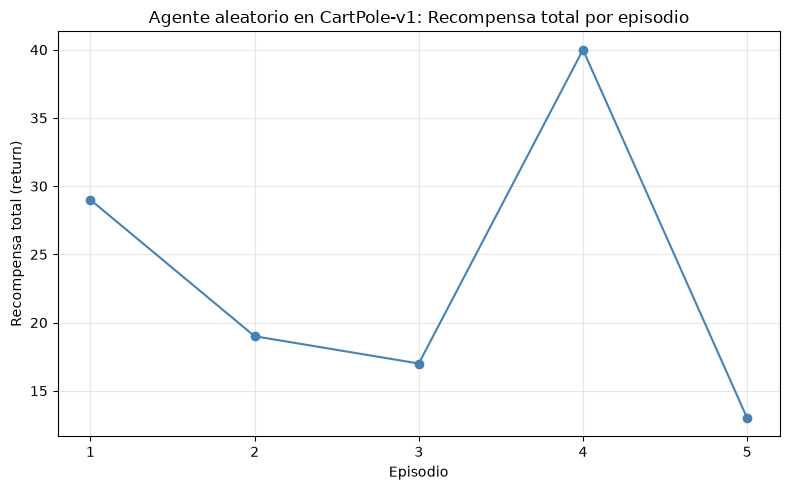

In [7]:
episodios = range(1, len(returns_cartpole) + 1)

plt.figure(figsize=(8, 5))
plt.plot(episodios, returns_cartpole, marker='o', linestyle='-', color='steelblue')
plt.title("Agente aleatorio en CartPole-v1: Recompensa total por episodio")
plt.xlabel("Episodio")
plt.ylabel("Recompensa total (return)")
plt.xticks(episodios)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Agente aleatorio en entorno discreto distinto

In [8]:
print("=== Agente aleatorio en FrozenLake-v1 ===")
steps_frozenlake, returns_frozenlake = run_random_agent("FrozenLake-v1", n_episodes=5)

=== Agente aleatorio en FrozenLake-v1 ===
Episodio 1: steps = 3, return = 0.0
Episodio 2: steps = 5, return = 0.0
Episodio 3: steps = 7, return = 0.0
Episodio 4: steps = 8, return = 0.0
Episodio 5: steps = 16, return = 0.0


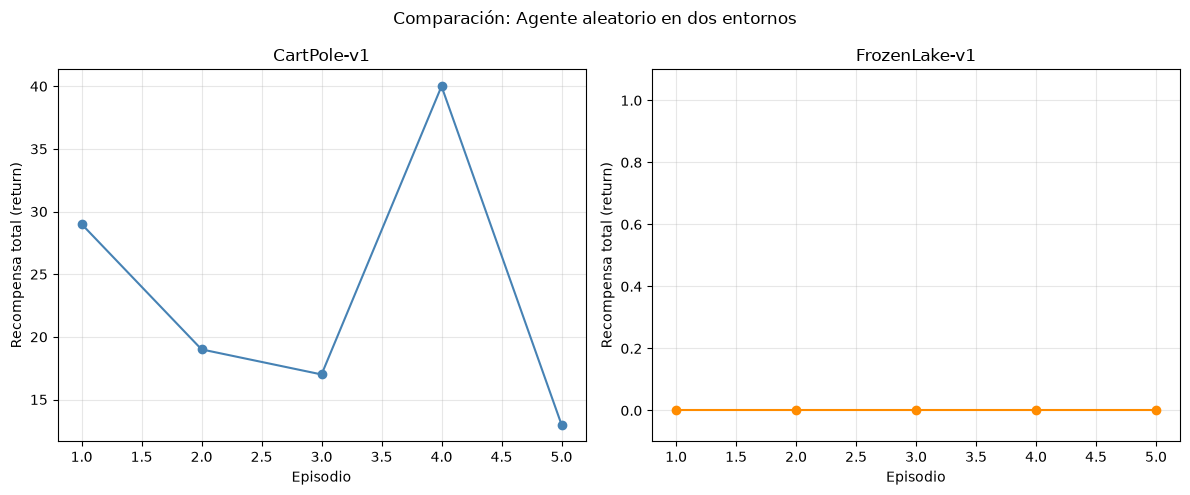

In [9]:
episodios = range(1, len(returns_cartpole) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(episodios, returns_cartpole, marker='o', color='steelblue')
axes[0].set_title("CartPole-v1")
axes[0].set_xlabel("Episodio")
axes[0].set_ylabel("Recompensa total (return)")
axes[0].grid(True, alpha=0.3)

axes[1].plot(episodios, returns_frozenlake, marker='o', color='darkorange')
axes[1].set_title("FrozenLake-v1")
axes[1].set_xlabel("Episodio")
axes[1].set_ylabel("Recompensa total (return)")
axes[1].set_ylim(-0.1, 1.1)
axes[1].grid(True, alpha=0.3)

plt.suptitle("Comparación: Agente aleatorio en dos entornos")
plt.tight_layout()
plt.show()

## Implementación de política simple

In [10]:
def simple_policy(observation):
    """
    Regla: si la velocidad angular del poste es positiva (cayendo hacia la derecha),
    empujar a la derecha (1); si es negativa, empujar a la izquierda (0).
    """
    angular_velocity = observation[3]
    return 1 if angular_velocity > 0 else 0


def run_simple_policy(env_name, n_episodes=5, seed=42):
    env = gym.make(env_name)
    steps_por_episodio = []
    returns_por_episodio = []

    for episodio in range(n_episodes):
        observation, info = env.reset(seed=seed + episodio)
        terminated = False
        truncated = False
        steps = 0
        total_reward = 0.0

        while not (terminated or truncated):
            action = simple_policy(observation)
            observation, reward, terminated, truncated, info = env.step(action)
            total_reward += reward
            steps += 1

        steps_por_episodio.append(steps)
        returns_por_episodio.append(total_reward)
        print(f"Episodio {episodio + 1}: steps = {steps}, return = {total_reward}")

    env.close()
    return steps_por_episodio, returns_por_episodio


print("=== Política simple en CartPole-v1 ===")
steps_simple, returns_simple = run_simple_policy("CartPole-v1", n_episodes=5)

=== Política simple en CartPole-v1 ===
Episodio 1: steps = 183, return = 183.0
Episodio 2: steps = 132, return = 132.0
Episodio 3: steps = 246, return = 246.0
Episodio 4: steps = 223, return = 223.0
Episodio 5: steps = 211, return = 211.0
